# Model Evaluation
### Chest X-Ray Classification: Normal vs Pneumonia vs COVID-19
This notebook evaluates both the baseline CNN and ResNet50 models using confusion matrix, precision, recall and F1-score per class.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pneumonia-detection/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pneumonia-detection/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warnin

In [2]:
# Device setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Dataset paths
data_dir = Path('../data/Dataset')
train_dir = data_dir / 'Train_Validation'
test_dir = data_dir / 'Test'
classes = ['COVID', 'Normal', 'Pneumonia']

Using device: mps


In [3]:
# Preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Dataset class
class XRayDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        for label, cls in enumerate(classes):
            class_dir = self.data_dir / cls
            for img_path in class_dir.glob('*'):
                self.image_paths.append(img_path)
                self.labels.append(label)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        label = self.labels[index]
        return image, label

# Create test dataset and loader
test_dataset = XRayDataset(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 341


In [4]:
# Load Baseline CNN
class BaseCNN(nn.Module):
    def __init__(self):
        super(BaseCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 3)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Load baseline model weights
baseline_model = BaseCNN().to(device)
baseline_model.load_state_dict(torch.load('../models/baseline_cnn.pth', map_location=device))
baseline_model.eval()
print("Baseline CNN loaded")

# Load ResNet50 model
resnet_model = models.resnet50(weights=None)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 3)
resnet_model.load_state_dict(torch.load('../models/resnet50.pth', map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()
print("ResNet50 loaded")

/var/folders/md/z42njwbn00bbw9kn9gqmhyx40000gn/T/ipykernel_57806/1889977641.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_model.load_state_dict(torch.load('.

Baseline CNN loaded


/var/folders/md/z42njwbn00bbw9kn9gqmhyx40000gn/T/ipykernel_57806/1889977641.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet_model.load_state_dict(torch.load('../

ResNet50 loaded


In [5]:
# Load fine-tuned ResNet50
resnet_finetuned = models.resnet50(weights=None)
resnet_finetuned.fc = nn.Linear(resnet_finetuned.fc.in_features, 3)
resnet_finetuned.load_state_dict(torch.load('../models/resnet50_finetuned.pth', 
                                             map_location=device, 
                                             weights_only=True))
resnet_finetuned = resnet_finetuned.to(device)
resnet_finetuned.eval()
print("Fine-tuned ResNet50 loaded")

Fine-tuned ResNet50 loaded


In [6]:
def get_predictions_with_proba(model, loader):
    """Get predictions, true labels and probability scores"""
    all_predictions = []
    all_labels = []
    all_proba = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)  # convert to probabilities
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_proba.extend(probabilities.cpu().numpy())
    
    return all_labels, all_predictions, np.array(all_proba)
    

In [7]:
def plot_roc_curves(labels, predictions_proba, model_name):
    """Plot ROC curve for each class"""
    # Binarize labels for multi-class ROC
    labels_bin = label_binarize(labels, classes=[0, 1, 2])
    
    plt.figure(figsize=(8, 6))
    
    colors = ['blue', 'green', 'red']
    
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], predictions_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, 
                label=f'{cls} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'../results/{model_name}_roc_curve.png')
    plt.show()

In [8]:
# Get predictions with probability scores for all three models
print("Evaluating Baseline CNN...")
baseline_labels, baseline_preds, baseline_proba = get_predictions_with_proba(baseline_model, test_loader)

print("Evaluating ResNet50 Feature Extraction...")
resnet_labels, resnet_preds, resnet_proba = get_predictions_with_proba(resnet_model, test_loader)

print("Evaluating ResNet50 Fine-tuned...")
finetuned_labels, finetuned_preds, finetuned_proba = get_predictions_with_proba(resnet_finetuned, test_loader)

print("Done")

Evaluating Baseline CNN...
Evaluating ResNet50 Feature Extraction...
Evaluating ResNet50 Fine-tuned...
Done


In [9]:
# Classification report for all three models
print("=" * 50)
print("BASELINE CNN - Classification Report")
print("=" * 50)
print(classification_report(baseline_labels, baseline_preds, target_names=classes))

print("=" * 50)
print("RESNET50 (Feature Extraction) - Classification Report")
print("=" * 50)
print(classification_report(resnet_labels, resnet_preds, target_names=classes))

print("=" * 50)
print("RESNET50 (Fine-tuned) - Classification Report")
print("=" * 50)
print(classification_report(finetuned_labels, finetuned_preds, target_names=classes))

BASELINE CNN - Classification Report
              precision    recall  f1-score   support

       COVID       0.71      0.91      0.80       116
      Normal       0.95      0.64      0.77       112
   Pneumonia       0.62      0.64      0.63       113

    accuracy                           0.73       341
   macro avg       0.76      0.73      0.73       341
weighted avg       0.76      0.73      0.73       341

RESNET50 (Feature Extraction) - Classification Report
              precision    recall  f1-score   support

       COVID       0.70      0.85      0.77       116
      Normal       0.91      0.90      0.91       112
   Pneumonia       0.74      0.58      0.65       113

    accuracy                           0.78       341
   macro avg       0.78      0.78      0.78       341
weighted avg       0.78      0.78      0.78       341

RESNET50 (Fine-tuned) - Classification Report
              precision    recall  f1-score   support

       COVID       0.82      0.94      0.88   

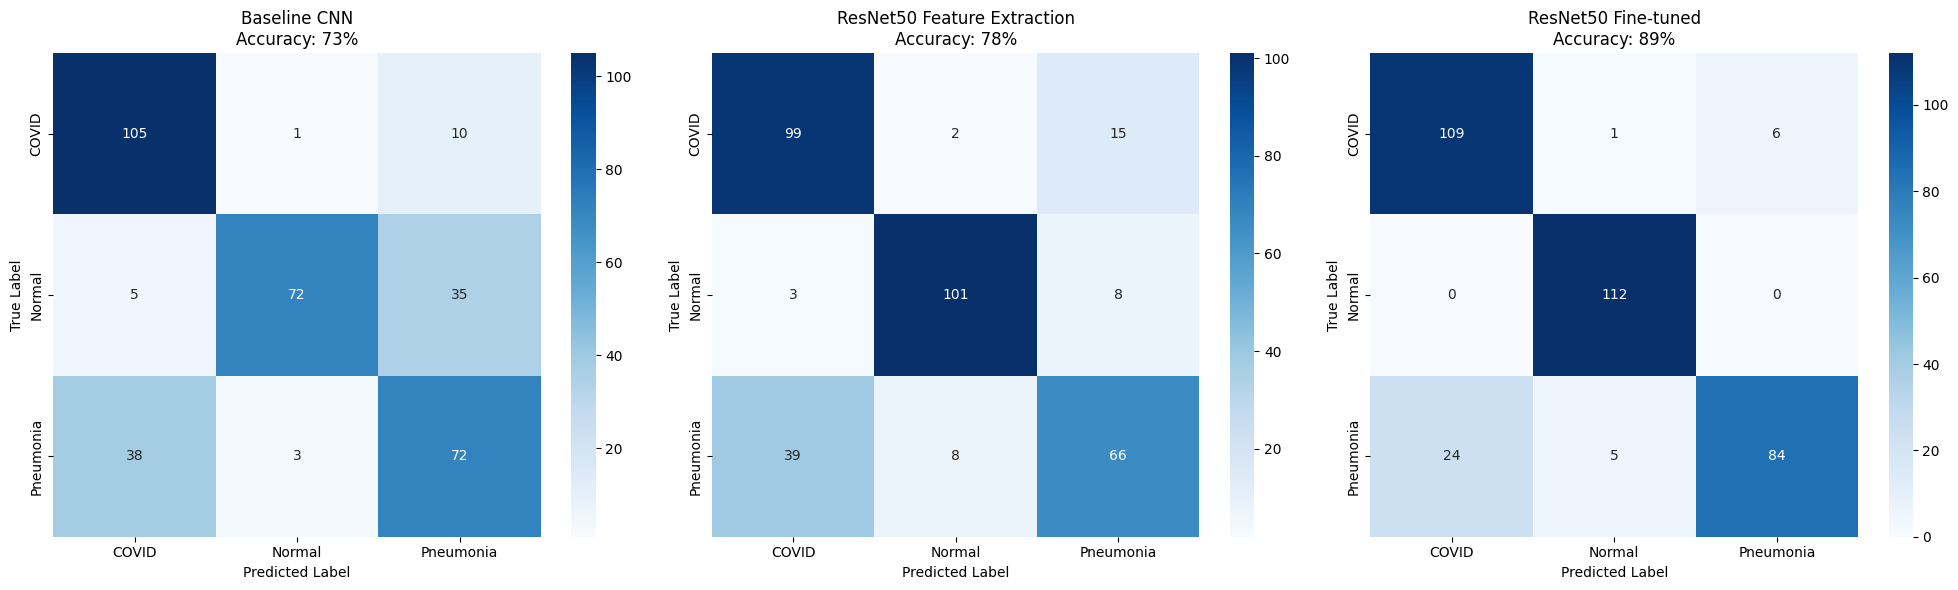

Saved to results folder


In [10]:
def plot_confusion_matrices(baseline_labels, baseline_preds, 
                            resnet_labels, resnet_preds,
                            finetuned_labels, finetuned_preds):
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Baseline CNN
    cm_baseline = confusion_matrix(baseline_labels, baseline_preds)
    sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title('Baseline CNN\nAccuracy: 73%')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # ResNet50 Feature Extraction
    cm_resnet = confusion_matrix(resnet_labels, resnet_preds)
    sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title('ResNet50 Feature Extraction\nAccuracy: 78%')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    # ResNet50 Fine-tuned
    cm_finetuned = confusion_matrix(finetuned_labels, finetuned_preds)
    sns.heatmap(cm_finetuned, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[2])
    axes[2].set_title('ResNet50 Fine-tuned\nAccuracy: 89%')
    axes[2].set_ylabel('True Label')
    axes[2].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('../results/confusion_matrices.png')
    plt.show()
    print("Saved to results folder")

plot_confusion_matrices(baseline_labels, baseline_preds,
                        resnet_labels, resnet_preds,
                        finetuned_labels, finetuned_preds)

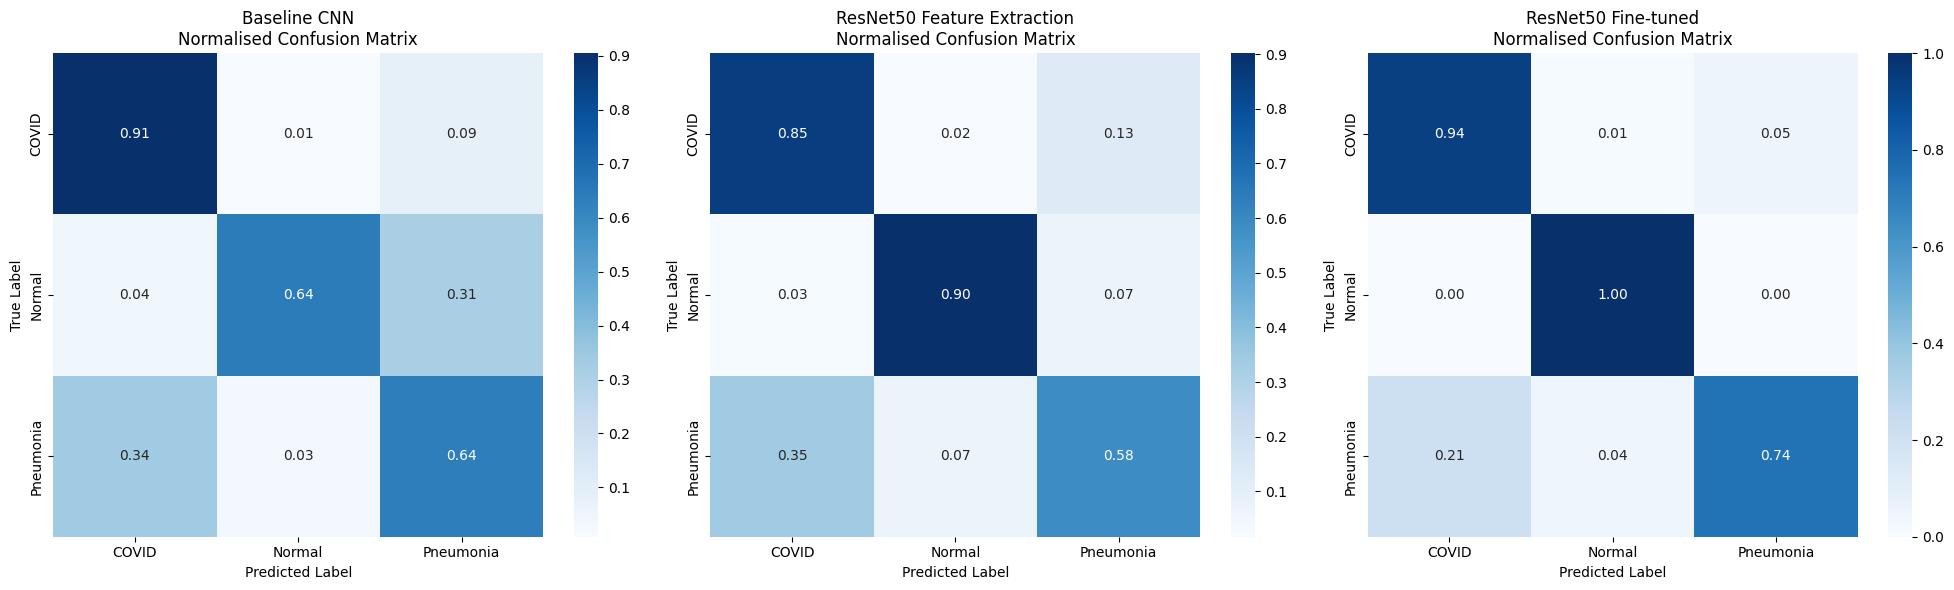

Saved to results folder


In [11]:
def plot_normalised_confusion_matrices(baseline_labels, baseline_preds,
                                        resnet_labels, resnet_preds,
                                        finetuned_labels, finetuned_preds):
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Baseline CNN - normalised
    cm_baseline = confusion_matrix(baseline_labels, baseline_preds, normalize='true')
    sns.heatmap(cm_baseline, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title('Baseline CNN\nNormalised Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # ResNet50 Feature Extraction - normalised
    cm_resnet = confusion_matrix(resnet_labels, resnet_preds, normalize='true')
    sns.heatmap(cm_resnet, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title('ResNet50 Feature Extraction\nNormalised Confusion Matrix')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    # ResNet50 Fine-tuned - normalised
    cm_finetuned = confusion_matrix(finetuned_labels, finetuned_preds, normalize='true')
    sns.heatmap(cm_finetuned, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[2])
    axes[2].set_title('ResNet50 Fine-tuned\nNormalised Confusion Matrix')
    axes[2].set_ylabel('True Label')
    axes[2].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('../results/normalised_confusion_matrices.png')
    plt.show()
    print("Saved to results folder")

plot_normalised_confusion_matrices(baseline_labels, baseline_preds,
                                    resnet_labels, resnet_preds,
                                    finetuned_labels, finetuned_preds)

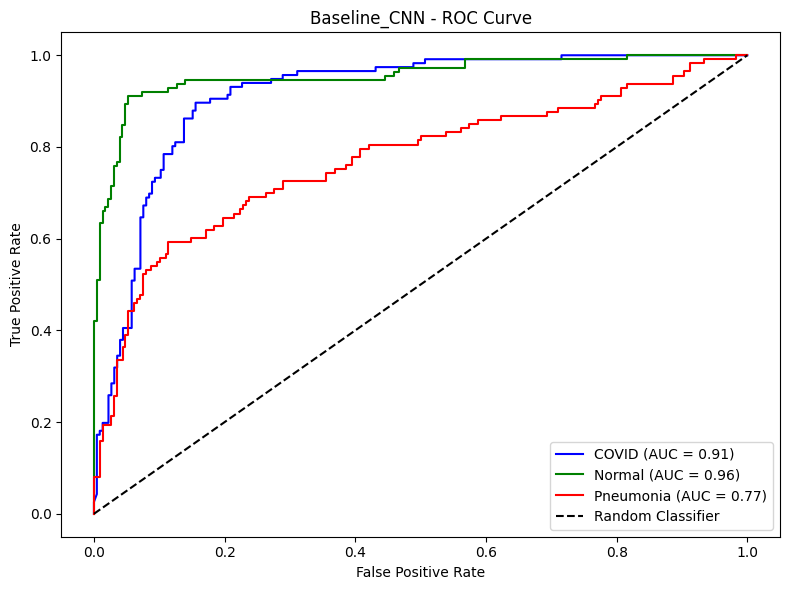

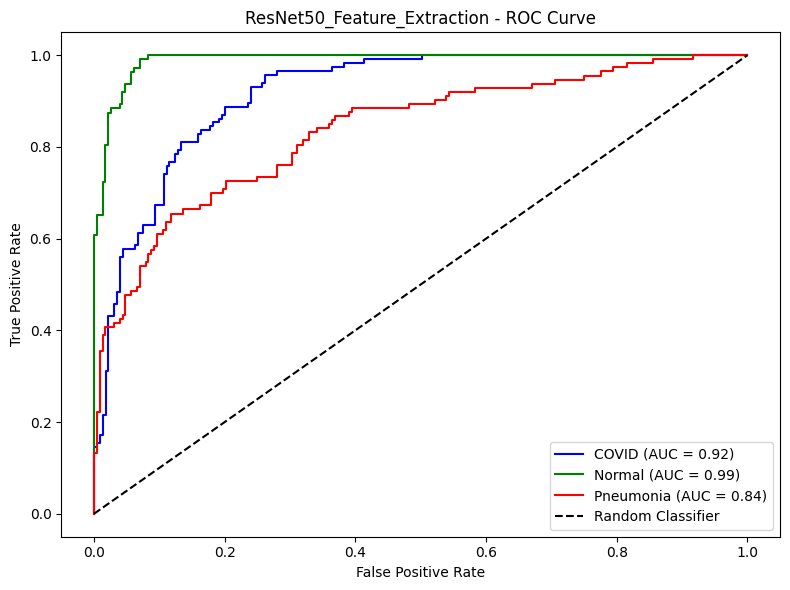

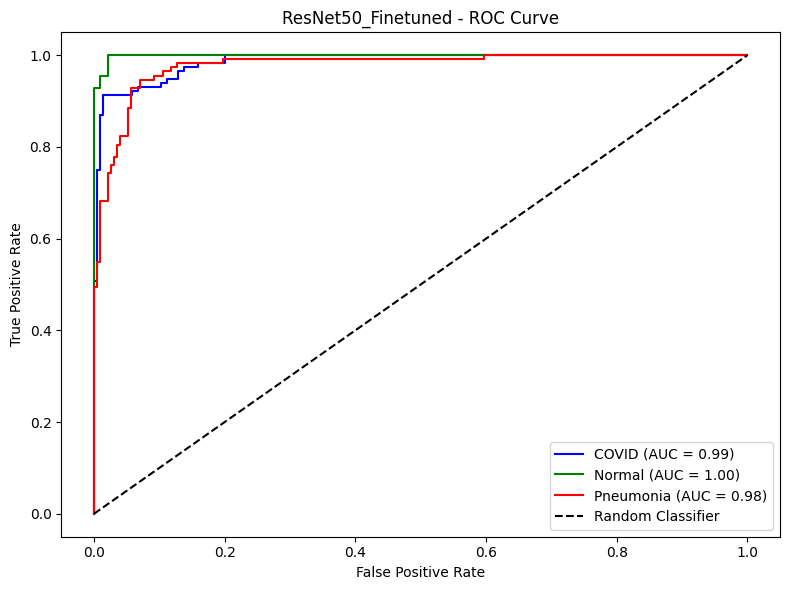

In [12]:
# Plot ROC curves for all three models
plot_roc_curves(baseline_labels, baseline_proba, 'Baseline_CNN')
plot_roc_curves(resnet_labels, resnet_proba, 'ResNet50_Feature_Extraction')
plot_roc_curves(finetuned_labels, finetuned_proba, 'ResNet50_Finetuned')

## Summary of Results

### Dataset
- 3,225 chest X-ray images across three classes: COVID-19, Normal, Pneumonia
- Radiologist-verified, balanced distribution (~1,075 images per class)
- Split: 80% training, 20% validation, separate test set (341 images)

### Model Comparison

| Model | Test Accuracy | COVID F1 | Normal F1 | Pneumonia F1 |
|-------|--------------|----------|-----------|--------------|
| Baseline CNN | 73% | 0.80 | 0.77 | 0.63 |
| ResNet50 (Feature Extraction) | 78% | 0.77 | 0.91 | 0.65 |
| ResNet50 (Fine-tuned) | 89% | 0.88 | 0.97 | 0.83 |

### AUC-ROC Results

| Model | COVID AUC | Normal AUC | Pneumonia AUC |
|-------|-----------|------------|---------------|
| Baseline CNN | 0.91 | 0.96 | 0.77 |
| ResNet50 (Feature Extraction) | 0.92 | 0.99 | 0.84 |
| ResNet50 (Fine-tuned) | 0.99 | 1.00 | 0.98 |

### Confusion Matrices

**Raw counts** show the actual number of images correctly and incorrectly classified. 
**Normalised matrices** show the proportion per class, making it easier to compare performance across classes regardless of dataset size. Both are included for completeness.

### Key Findings
- Fine-tuned ResNet50 outperformed baseline CNN by 16% on test accuracy
- Normal classification nearly perfect at F1=0.97
- COVID and Pneumonia remain most confused classes — clinically expected
- Fine-tuning unfrozen layers gave 11% improvement over feature extraction alone
- Data augmentation reduced overfitting significantly

### Limitations
- Pneumonia recall at 74% — 26% of pneumonia cases still missed
- Small dataset size limits generalisation
- Further improvement possible with larger dataset and longer training